In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,r2_score 
from sklearn.model_selection import train_test_split
plt.rcParams['figure.figsize']=(12.0, 9.0)

In [2]:
np.random.seed(42)
X=np.arange(1,21)
Y=2*X+1+np.random.normal(0,2,20)

In [3]:
data=pd.DataFrame({'X':X,'Y':Y})
data.to_csv('data.csv',index=False)
print("Dataset created successfully!")
print(data.head())

Dataset created successfully!
   X          Y
0  1   3.993428
1  2   4.723471
2  3   8.295377
3  4  12.046060
4  5  10.531693


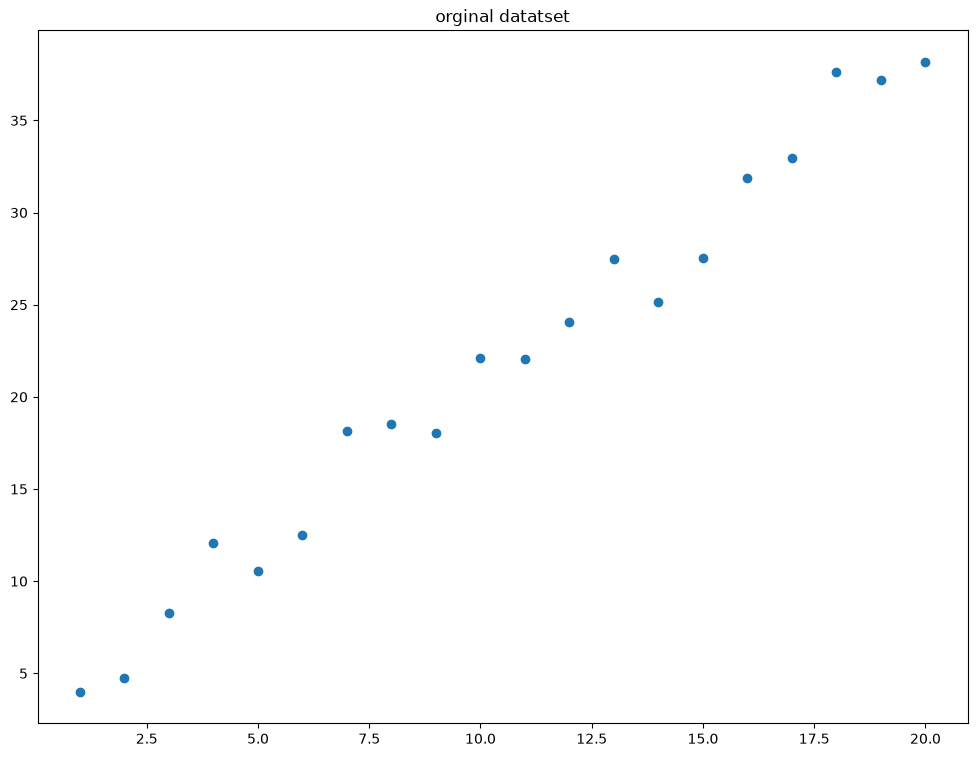

In [4]:
data=pd.read_csv('data.csv')
X=data.iloc[:,0]
Y=data.iloc[:,1]
plt.scatter(X,Y)
plt.title("orginal datatset")
plt.show()

In [5]:
def manual_linear_regression(X_train ,Y_train):
    X_mean=np.mean(X_train)
    Y_mean=np.mean(Y_train)
    num=0
    den=0
    for i in range(len(X_train)):
        num+=(X_train.iloc[i]-X_mean)*(Y_train.iloc[i]-Y_mean)
        den += (X_train.iloc[i]-X_mean)**2
    m=num/den
    c=Y_mean-m*X_mean
    return m,c

X_train_80,X_test_20,Y_train_80,Y_test_20=train_test_split(X,Y,test_size=0.2,random_state=42)

X_train_70,X_test_30,Y_train_70,Y_test_30=train_test_split(X,Y,test_size=0.3,random_state=42)



In [6]:
m_80,c_80=manual_linear_regression(X_train_80,Y_train_80)
Y_pred_80=m_80*X_test_20+c_80

In [12]:
m_70,c_70=manual_linear_regression(X_train_70,Y_train_70)
Y_pred_70=m_70*X_test_30+c_70

In [9]:
MSE_80 = mean_squared_error(Y_test_20,Y_pred_80)
accuracy_80=r2_score(Y_test_20,Y_pred_80)

print("80-20 Split Results:")
print(f"Slope(m):{m_80:.4f}")
print(f"Intercept(c):{c_80:.4f}")
print(f"MSE: {MSE_80:.4f}")
print(f"Accuracy(R^2 Score): {accuracy_80:.4f}")

80-20 Split Results:
Slope(m):1.7065
Intercept(c):3.7318
MSE: 4.6926
Accuracy(R^2 Score): 0.9800


In [10]:
from sklearn.linear_model import LinearRegression


In [14]:
model=LinearRegression()
model.fit(X_train_70.to_frame(),Y_train_70)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.68]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['X']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
